In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from Problem4 import PS3_Problem4

Build rate tensor K with k_p1=2000.0, k_m1=3e-12, k_p2=20.0
Shape of K: (5, 5, 5)


Initialize

In [2]:
p4=PS3_Problem4()

Build rate tensor K with k_p1=2000.0, k_m1=3e-12, k_p2=20.0
Shape of K: (5, 5, 5)


In [3]:
X0=jnp.array([0.01, 0.01, 0.75, 0.23, 0.00])

(a)
Compute the eigenvalues. We can find that λ_max/λ_min﹥1.

In [4]:
p4.calculate_Jacobian(X0)

Eigenvalues: [-1.52454025e+03+0.j  8.32403518e-15+0.j -2.59750440e-01+0.j
  1.13746124e-15+0.j -9.86076132e-32+0.j]
Stiffness: 1.5460674899418758e+34


(b)

We want to solve this function. 
The default timestep is 1e-4.

(b)i. Fourth-orderRunge-Kutta(RK4)

Using Dopri5 with ConstantStepSize is the correct "spiritual" equivalent to RK4 in a modern library.

4.45 s ± 446 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

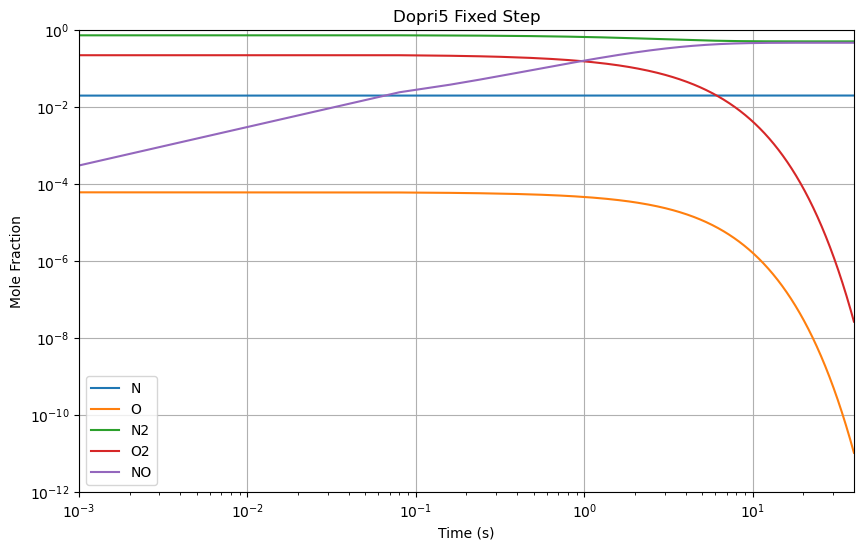

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[500],
  ys=f64[500,5],
  interpolation=None,
  stats={
    'max_steps': weak_i64[],
    'num_accepted_steps': weak_i64[],
    'num_rejected_steps': weak_i64[],
    'num_steps': weak_i64[]
  },
  result=diffrax._solution.RESULTS<>,
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)

In [5]:
#%%timeit
p4.solve(X0, method='Dopri5', adaptive=False,plot=True)

(b)ii. Second-orderDiagonallyImplicitRunge-Kutta(DIRK2).

(b)iii. Second-orderImplicitBackwardDifferentiationFormulas(BDF2).

For a second-order requirement, we use Kvaerno3 (which is 3rd order but serves the same functional purpose)

Since the problem specifically asks for a fixed-step solver, I have to explicitly pass the tolerances into the nonlinear solver (the root_finder) inside the integrator.

10.7 s ± 140 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

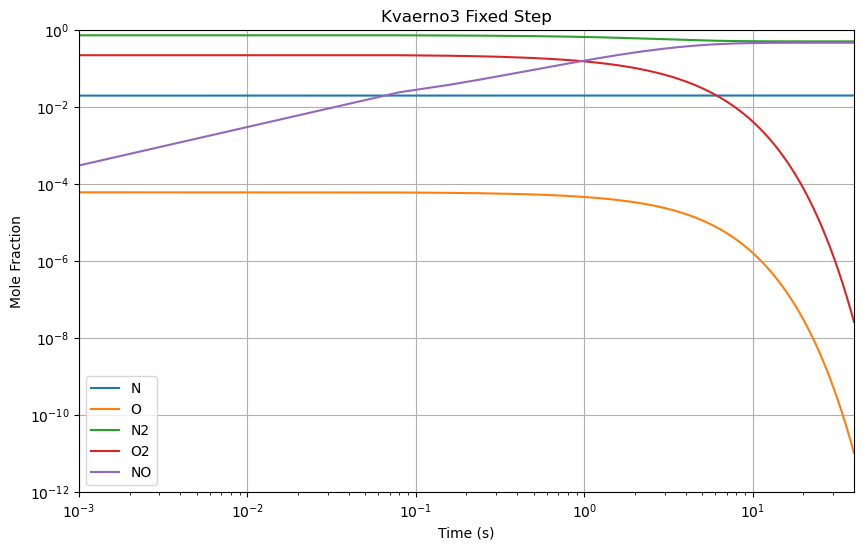

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[500],
  ys=f64[500,5],
  interpolation=None,
  stats={
    'max_steps': weak_i64[],
    'num_accepted_steps': weak_i64[],
    'num_rejected_steps': weak_i64[],
    'num_steps': weak_i64[]
  },
  result=diffrax._solution.RESULTS<>,
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)

In [6]:
#%%timeit
p4.solve(X0, method='Kvaerno3', adaptive=False,plot=True)

(b)iv. (ii.) with adaptive time-stepping.

(b)v. (iii.) with adaptive time-stepping.

With adaptive timestep. We can find that the computational cost decreases significantly.

470 ms ± 5.08 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

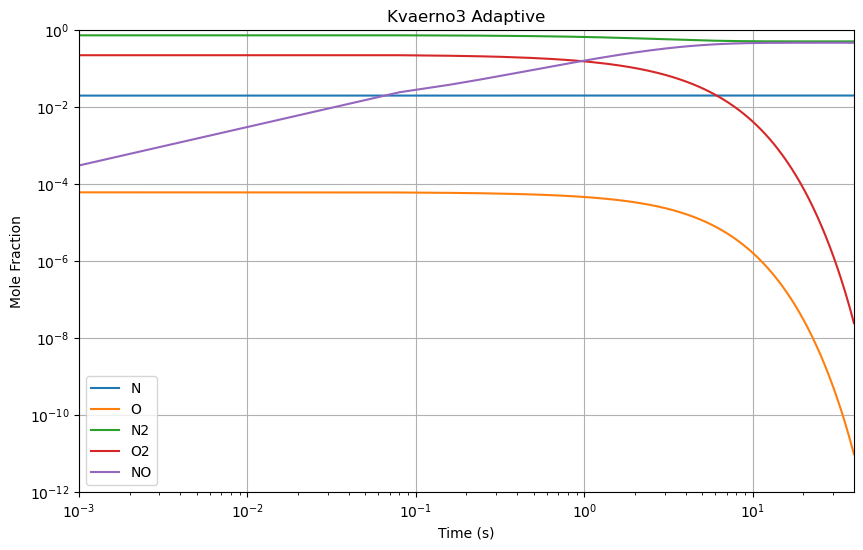

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[500],
  ys=f64[500,5],
  interpolation=None,
  stats={
    'max_steps': weak_i64[],
    'num_accepted_steps': weak_i64[],
    'num_rejected_steps': weak_i64[],
    'num_steps': weak_i64[]
  },
  result=diffrax._solution.RESULTS<>,
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)

In [7]:
#%%timeit
p4.solve(X0, method='Kvaerno3', adaptive=True,plot=True)